# **Задание №4. Проектирование базы данных для информационной системы**

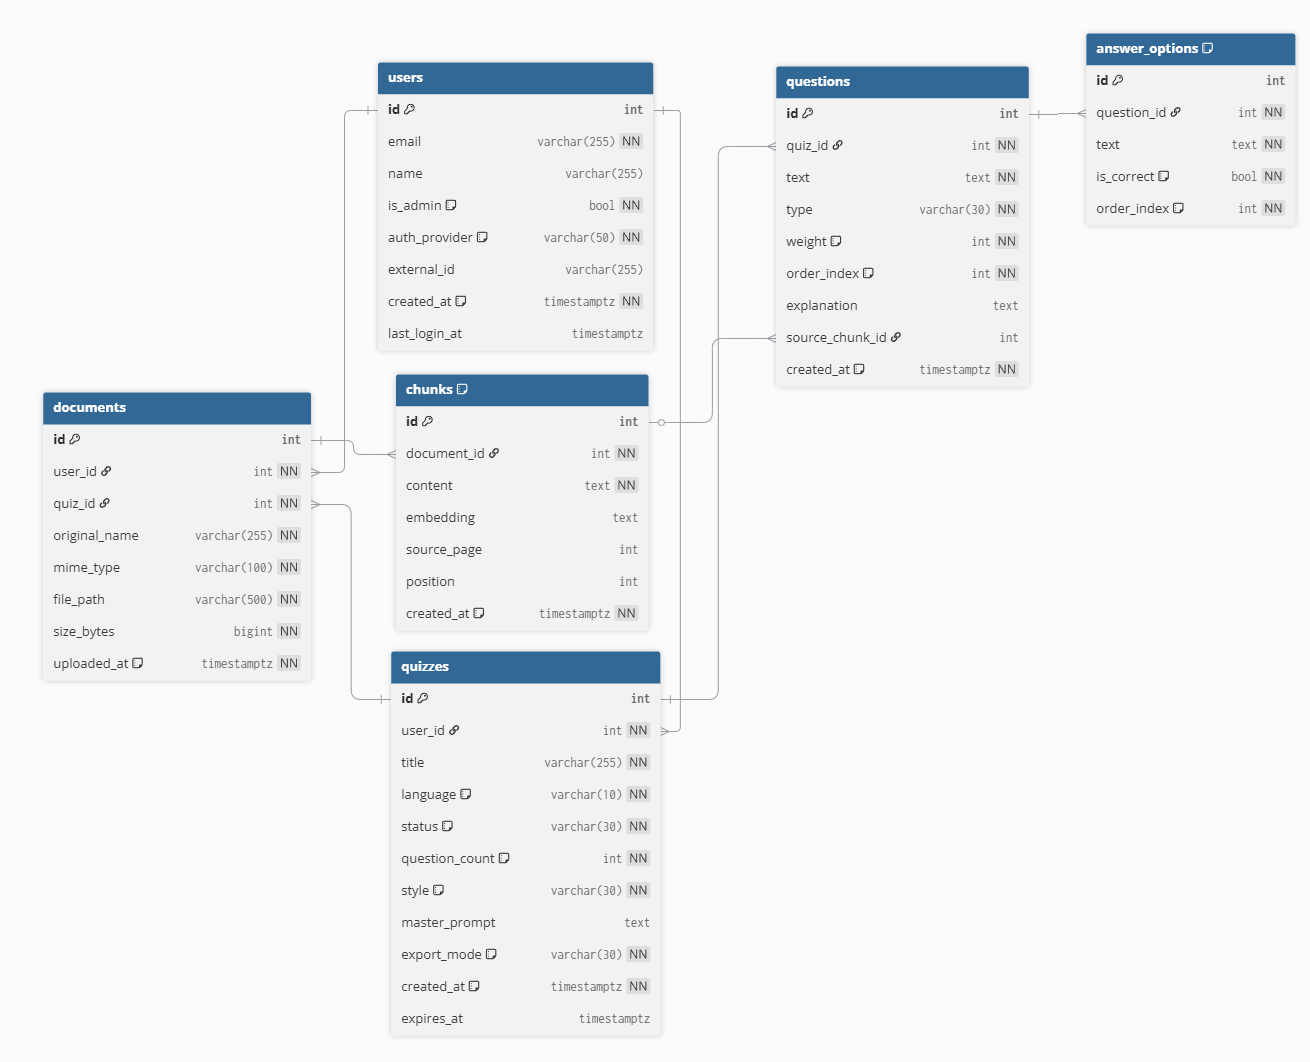

# ER-модель: текстовое описание сущностей


## **users - данные о пользователях системы**

Эта сущность хранит учетные записи всех пользователей, включая обычных авторов квизов и администраторов. Таблица используется для авторизации, контроля доступа и ведения статистики.

**Поля:**

* **id** - уникальный идентификатор пользователя, используется для связи с другими таблицами.
* **email** - основной идентификатор учетной записи, полученный из Google или введенный вручную.
* **name** - имя пользователя, обычно импортируется из Google OAuth.
* **is_admin** - флаг, который определяет, является ли пользователь администратором.
* **auth_provider** - источник авторизации (google или local), что позволяет расширять систему.
* **external_id** - внешний уникальный идентификатор, например sub из Google.
* **created_at** - дата регистрации, используется для статистики.
* **last_login_at** - время последнего входа, помогает отслеживать активность.


## **quizzes - квизы, созданные пользователями**

Сущность хранит информацию о каждом квизе: название, параметры генерации и срок его жизни. Квиз всегда привязан к одному пользователю и имеет ограниченный срок хранения (3 дня).

**Поля:**

* **id** - уникальный идентификатор квиза.
* **user_id** - владелец квиза, связь с users.
* **title** - название квиза, отображается в списке.
* **language** - язык квиза (обычно ru).
* **status** - текущее состояние квиза (active, expired, deleted).
* **question_count** - количество вопросов, которое планировалось при генерации.
* **style** - стиль формулировки вопросов (строгий, юмористический, академический).
* **master_prompt** - пользовательский промпт, влияющий на генерацию.
* **export_mode** - выбранный режим формирования PPTX (ответы в конце или после каждого вопроса).
* **created_at** - время создания квиза.
* **expires_at** - дата автоудаления, используемая фоновым процессом очистки.


## **documents - загруженные файлы для генерации квиза**

Здесь хранятся сведения о документах, на основе которых строится RAG. Каждый документ принадлежит конкретному пользователю и конкретному квизу.

**Поля:**

* **id** - идентификатор документа.
* **user_id** - кто загрузил документ.
* **quiz_id** - квиз, для которого был загружен документ.
* **original_name** - имя файла, как оно называлось у пользователя.
* **mime_type** - тип содержимого (PDF, DOCX, TXT, HTML).
* **file_path** - путь в локальной файловой системе.
* **size_bytes** - размер файла для проверки ограничений.
* **uploaded_at** - время загрузки, используется для контроля хранения.


## **chunks - текстовые фрагменты документов (RAG)**

Сущность хранит нарезанные части текстов, полученные после обработки документов. Чанки используются в векторном поиске для генерации релевантных вопросов.

**Поля:**

* **id** - идентификатор чанка.
* **document_id** - какой документ породил этот фрагмент.
* **content** - текстовая часть документа, подготовленная для RAG.
* **embedding** - векторное представление текста (в реальной БД хранится через pgvector).
* **source_page** - номер страницы исходного документа (если применимо).
* **position** - порядковый номер чанка внутри документа.
* **created_at** - время формирования чанка, нужно для очистки.


## **questions - список вопросов, принадлежащих квизу**

Сущность содержит вопросы, сгенерированные LLM или добавленные вручную пользователем. Поддерживаются разные типы вопросов, порядок и вес.

**Поля:**

* **id** - идентификатор вопроса.
* **quiz_id** - квиз, которому принадлежит вопрос.
* **text** - текст вопроса, который видит пользователь.
* **type** - тип вопроса (single, multiple, open, matching).
* **weight** - вес вопроса для последующей оценки или сортировки.
* **order_index** - порядок отображения на экране и в PPTX.
* **explanation** - дополнительное пояснение, если нужно.
* **source_chunk_id** - ссылка на чанк, по которому был создан вопрос (метаданные происхождения).
* **created_at** - дата добавления вопроса.


## **answer_options - варианты ответов для вопросов**

Сущность описывает варианты ответа для вопросов типов single/multiple/matching. Для open-вопросов варианты могут отсутствовать.

**Поля:**

* **id** - идентификатор варианта ответа.
* **question_id** - связь с конкретным вопросом.
* **text** - текст варианта ответа.
* **is_correct** - правильный ли это вариант (для open-вопросов всегда false).
* **order_index** - порядок отображения варианта в списке.